In [49]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
def f(x):
    return 3*x**2 -4*x + 5

In [ ]:
f(3.0)

In [ ]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
h = 0.0000000001
x = 2/3
(f(x + h) - f(x))/h


In [ ]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

In [ ]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
# a += h
# b += h
c += h
d2 = a*b + c

print('d1 =', d1)
print('d2 =', d2)
print('slope =', (d2 - d1)/h)

In [115]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out  = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self / other
        return self * (other**-1)

    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __radd__(self, other): # other + self
        return self + other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
            
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out

    def backward(self):

        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [78]:
a = Value(2.0)
b = Value(4.0)
a - b

Value(data=-2.0)

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

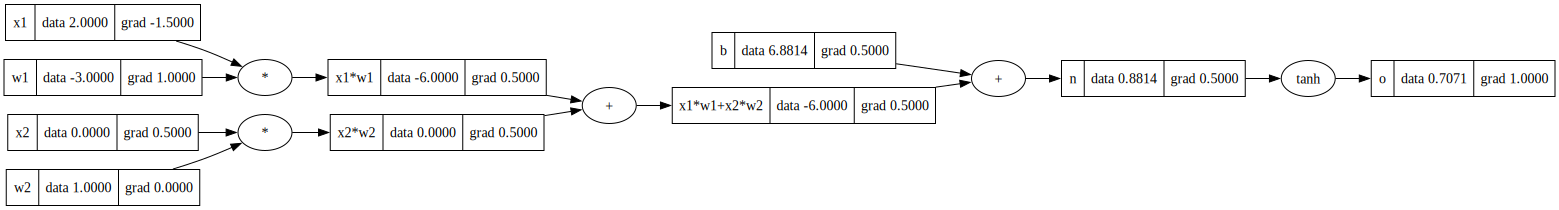

In [79]:
# input x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias b
b = Value(6.881373587019543, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1+x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

o.backward()
draw_dot(o)


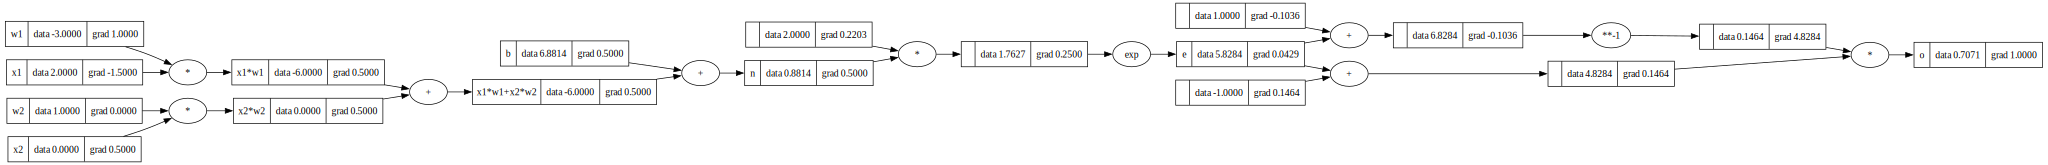

In [81]:
# input x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias b
b = Value(6.881373587019543, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1+x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e = (2*n).exp(); e.label = 'e'
o = (e - 1)/(e + 1); o.label = 'o'

o.backward()
draw_dot(o)


In [83]:
import torch

In [ ]:
x1 = torch.Tensor([2.0]).double()       ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()       ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()      ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()       ; w2.requires_grad = True
b = torch.Tensor([6.881373587019543]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())


0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737
tensor([0.5000], dtype=torch.float64)


In [163]:
import random

class Neuron:

    def __init__(self, nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out
        
    def parameters(self):
        return self.w + [self.b]


class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()] 

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]



In [217]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.37230496262427026)

In [214]:
n.parameters()

[Value(data=-0.8187644517830139),
 Value(data=0.17920158232534078),
 Value(data=-0.06653899864359758),
 Value(data=-0.33129718211574577),
 Value(data=-0.16597117343760748),
 Value(data=0.06765669134517127),
 Value(data=-0.40002322066328144),
 Value(data=0.3674287846755624),
 Value(data=-0.4524196655995072),
 Value(data=-0.4879662743714652),
 Value(data=-0.0659511713977694),
 Value(data=-0.3395775237253178),
 Value(data=0.2652024051418538),
 Value(data=0.4135390710358544),
 Value(data=0.8163346551431601),
 Value(data=-0.08311626746901712),
 Value(data=0.7326959249944822),
 Value(data=0.15824722754318898),
 Value(data=0.2124325301231229),
 Value(data=-0.3411838492248094),
 Value(data=0.719748220523539),
 Value(data=0.10612859750139969),
 Value(data=0.2282352032156132),
 Value(data=-0.6919598208264159),
 Value(data=0.3573440041246443),
 Value(data=-0.7979716229191847),
 Value(data=-0.30992202189757223),
 Value(data=-0.17812433472787914),
 Value(data=-0.8784304049135434),
 Value(data=0.415

In [218]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0]
]
ys = [1.0, -1.0, -1.0, 1.0]


In [197]:
ypred = [n(x) for x in xs] 
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.99867993128495)

In [227]:
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs] 
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
    loss

    # backward pass
    for p in n.parameters():
        p.grad = 0
    loss.backward()

    # update weights
    for p in n.parameters():
        p.data -= 0.1 * p.grad
    
    print(f'{k} loss: {loss.data}')
        

0 loss: 0.004687685838400644
1 loss: 0.004631010924861923
2 loss: 0.004575618648029636
3 loss: 0.004521466705572844
4 loss: 0.004468514620488553
5 loss: 0.004416723644113038
6 loss: 0.004366056665237131
7 loss: 0.004316478124882514
8 loss: 0.0042679539363329674
9 loss: 0.0042204514100461984
10 loss: 0.00417393918310357
11 loss: 0.004128387152880949
12 loss: 0.0040837664146496835
13 loss: 0.004040049202838964
14 loss: 0.003997208835711831
15 loss: 0.003955219663225995
16 loss: 0.003914057017867953
17 loss: 0.0038736971682646094
18 loss: 0.003834117275391697
19 loss: 0.003795295351210878


In [228]:
ypred

[Value(data=0.978267336163055),
 Value(data=-0.965084849462151),
 Value(data=-0.9723673469903408),
 Value(data=0.9633891351600603)]

In [168]:
n.layers[0].neurons[0].w[0].grad

0.6368524476046263

In [169]:
n.layers[0].neurons[0].w[0].data

-0.052852413516682795

In [206]:
for p in n.parameters():
    p.data -= 0.01 * p.grad

In [176]:
n.layers[0].neurons[0].w[0].data

-0.07780658940025191